# Explora aquí

Se recomienda utilizar este cuaderno con fines de exploración.

In [1]:
!pip install lxml html5lib

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
from bs4 import BeautifulSoup
import requests
import time
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import io
import pandas as pd



In [3]:
url = "https://en.wikipedia.org/wiki/List_of_most-streamed_songs_on_Spotify"
headers = {'User-Agent':'Mozilla/5.0 (Linux; Android 10; K) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Mobile Safari/537.36'}
response = requests.get(url,headers=headers)
print("Estado: ",response.status_code)

Estado:  200


In [4]:
#Opcion 1: Leer directo con Pandas

html = io.StringIO(response.text)
tablas = pd.read_html(html)
print(len(tablas))
df = tablas[0]
df = df.drop(100)
df.tail()


29


,Rank,Song,Artist(s),Streams (billions),Release date,Ref.
95,96,"""Uptown Funk""",Mark Ronson and Bruno Mars,2.663,10 November 2014,[96]
96,97,"""Good 4 U""",Olivia Rodrigo,2.651,14 May 2021,[97]
97,98,"""One of the Girls""","The Weeknd, Jennie and Lily-Rose Depp",2.649,23 June 2023,NaN
98,99,"""End of Beginning""",Djo,2.647,16 September 2022,NaN
99,100,"""Happier""",Marshmello and Bastille,2.617,16 August 2018,NaN


In [5]:
conn = sqlite3.connect("spotify.db")

In [6]:
df.to_sql('mas_reproducidas',conn,if_exists='replace',index=False)

100

In [7]:
cursor = conn.cursor()
cursor.execute('SELECT * from mas_reproducidas limit 5')
print(cursor.fetchall())

conn.commit()
cursor.close()
conn.close()

[('1', '"Blinding Lights"', 'The Weeknd', '5.428', '29 November 2019', '[1]'), ('2', '"Shape of You"', 'Ed Sheeran', '4.927', '6 January 2017', '[2]'), ('3', '"Sweater Weather"', 'The Neighbourhood', '4.628', '3 December 2012', '[3]'), ('4', '"Starboy"', 'The Weeknd with Daft Punk', '4.553', '21 September 2016', '[4]'), ('5', '"As It Was"', 'Harry Styles', '4.429', '1 April 2022', '[5]')]


In [8]:
df.columns

Index(['Rank', 'Song', 'Artist(s)', 'Streams (billions)', 'Release date',
       'Ref.'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Rank                100 non-null    str  
 1   Song                100 non-null    str  
 2   Artist(s)           100 non-null    str  
 3   Streams (billions)  100 non-null    str  
 4   Release date        100 non-null    str  
 5   Ref.                97 non-null     str  
dtypes: str(6)
memory usage: 4.8 KB


In [10]:
df['Streams (billions)'] = df['Streams (billions)'].astype(float)

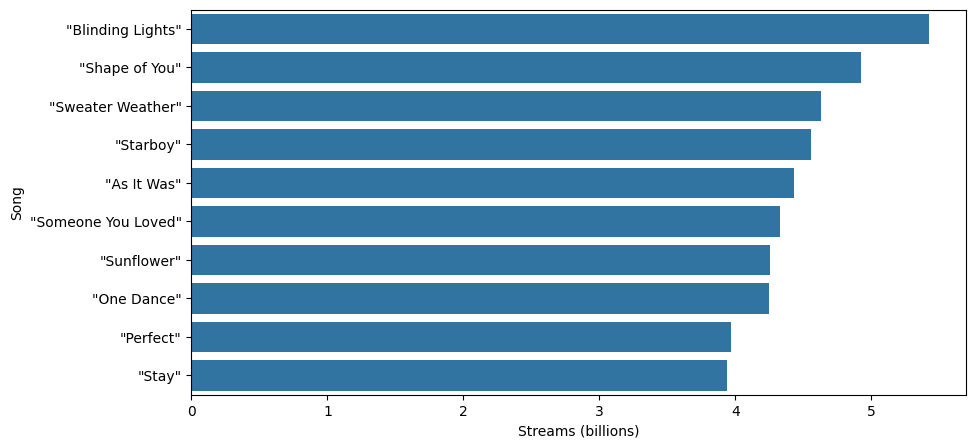

In [11]:
top10 = df.head(10)
plt.figure(figsize=(10,5))
sns.barplot(data=top10,y='Song',x='Streams (billions)')
plt.show()

In [12]:
df['Release date'] = pd.to_datetime(df['Release date'],errors='coerce')


In [13]:
df['Year'] = df['Release date'].dt.year

In [14]:
df.head(5)

,Rank,Song,Artist(s),Streams (billions),Release date,Ref.,Year
0,1,"""Blinding Lights""",The Weeknd,5.428,2019-11-29,[1],2019
1,2,"""Shape of You""",Ed Sheeran,4.927,2017-01-06,[2],2017
2,3,"""Sweater Weather""",The Neighbourhood,4.628,2012-12-03,[3],2012
3,4,"""Starboy""",The Weeknd with Daft Punk,4.553,2016-09-21,[4],2016
4,5,"""As It Was""",Harry Styles,4.429,2022-04-01,[5],2022


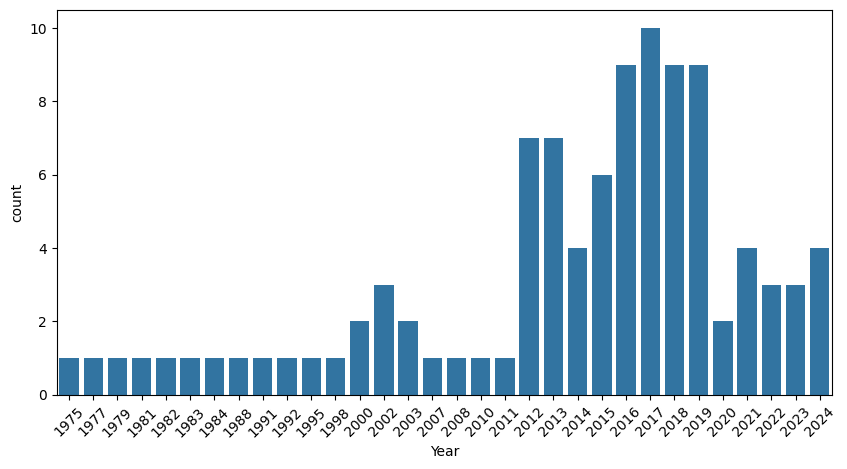

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='Year')
plt.xticks(rotation=45)
plt.show()

In [16]:
df1975 = df[df['Year']==1975]
df1975

,Rank,Song,Artist(s),Streams (billions),Release date,Ref.,Year
44,45,"""Bohemian Rhapsody""",Queen,3.165,1975-10-31,[45],1975


In [17]:
artistas = df['Artist(s)'].value_counts()

In [18]:
artistas = artistas[artistas > 2]

In [19]:
artistas

Artist(s)
The Weeknd         4
Ed Sheeran         4
Bruno Mars         4
Imagine Dragons    3
Arctic Monkeys     3
Coldplay           3
Name: count, dtype: int64

/tmp/ipykernel_27986/2527791592.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=artistas, y =artistas.index,palette='coolwarm')


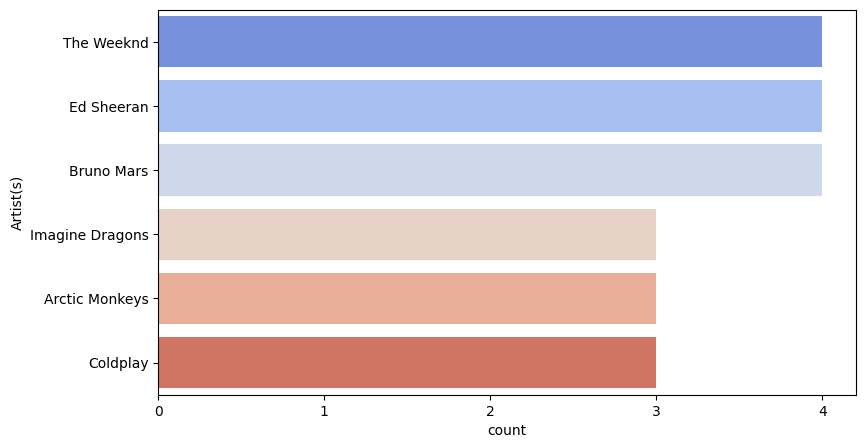

In [23]:
plt.figure(figsize=(9,5))
sns.barplot(x=artistas, y =artistas.index,palette='coolwarm')
plt.xticks(range(0,5))
plt.show()